# Compare MLP and CNN Models
> for Fashion MNIST Dataset Classification

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras import datasets, layers, Model, optimizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

## 1- Data Preparation

In [3]:
(train_images, train_labels), (test_images, test_labels) = datasets.fashion_mnist.load_data()

In [4]:
train_images.shape

(60000, 28, 28)

In [5]:
test_images.shape

(10000, 28, 28)

In [12]:
class_names = {0: 'T-shirt/top',
               1: 'Trouser',
               2: 'Pullover',
               3: 'Dress',
               4: 'Coat',
               5: 'Sandal',
               6: 'Shirt',
               7: 'Sneaker',
               8: 'Bag',
               9: 'Ankle boot'}

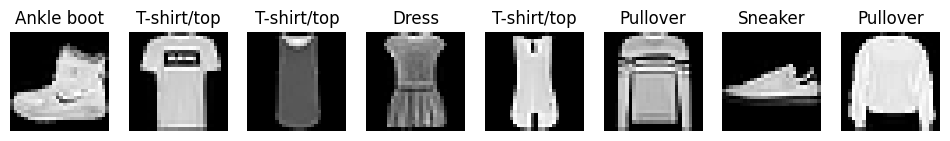

In [13]:
fig, axes = plt.subplots(1, 8, figsize=(12, 8))
for i, ax in enumerate(axes):
    ax.imshow(train_images[i], cmap='gray')
    ax.set_title(class_names[train_labels[i]])
    ax.set_axis_off()
plt.show()

### Pre-processing

In [22]:
X_train_ = train_images / 255.
X_test_ = test_images / 255.

In [23]:
X_train, X_val, y_train, y_val = train_test_split(X_train_, train_labels,
                                                  test_size=0.2,
                                                  stratify=train_labels)

In [39]:
print('Train class distribution:\n', np.bincount(y_train) / len(y_train))
print('Validation class distribution:\n', np.bincount(y_val) / len(y_val))

Train class distribution:
 [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Validation class distribution:
 [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


In [33]:
X_train_mlp = X_train.reshape(-1, 28*28)
X_val_mlp = X_val.reshape(-1, 28*28)
X_test_mlp = X_test.reshape(-1, 28*28)

In [34]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_val_cnn = X_val.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

## 2- Model Design

### MLP Model

In [91]:
inp = layers.Input(shape=(784,))
x = layers.Dense(32, activation='relu')(inp)
x = layers.Dropout(0.10)(x)
x = layers.Dense(16, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(8, activation='relu')(x)
out = layers.Dense(10, activation='softmax')(x)

model_mlp = Model(inputs=inp, outputs=out)
model_mlp.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)          │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 10)                  │              90 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,874 (101.07 KB)

 Trainable params: 25,874 (101.07 KB)

 Non-trainable params: 0 (0.00 B)

### CNN Model

In [97]:
inp = layers.Input(shape=(28, 28, 1))

x = layers.Conv2D(16, 3, padding='same')(inp)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)

x = layers.MaxPool2D()(x)

x = layers.Conv2D(28, 3, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)

x = layers.MaxPool2D()(x)
x = layers.Flatten()(x)
x = layers.Dense(15, activation='relu')(x)
out = layers.Dense(10, activation='softmax')(x)

model_cnn = Model(inputs=inp, outputs=out)
model_cnn.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)          │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 28, 28, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 28, 28, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 14, 14, 28)          │           4,060 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 14, 14, 28)          │             112 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 14, 14, 28)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (None, 7, 7, 28)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_8 (Flatten)                  │ (None, 1372)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 15)                  │          20,595 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 10)                  │             160 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,151 (98.25 KB)

 Trainable params: 25,063 (97.90 KB)

 Non-trainable params: 88 (352.00 B)

## 3- Training

In [98]:
model_mlp.compile(optimizer=optimizers.Adam(learning_rate=0.003),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [93]:
history_mlp = model_mlp.fit(X_train_mlp, y_train,
                            epochs=30, batch_size=128,
                            validation_data=(X_val_mlp, y_val))

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4901 - loss: 1.2969 - val_accuracy: 0.7447 - val_loss: 0.6299
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6533 - loss: 0.8841 - val_accuracy: 0.8119 - val_loss: 0.5594
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6981 - loss: 0.8001 - val_accuracy: 0.8193 - val_loss: 0.5390
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7158 - loss: 0.7625 - val_accuracy: 0.8263 - val_loss: 0.5065
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7304 - loss: 0.7352 - val_accuracy: 0.8306 - val_loss: 0.5007
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7390 - loss: 0.7135 - val_accuracy: 0.8280 - val_loss: 0.5066
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7451 - loss: 0.6985 - val_accuracy: 0.8423 - val_loss: 0.4756
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7549 - loss: 0.6812 - val_accuracy: 0.

In [99]:
history_cnn = model_cnn.fit(X_train_cnn, y_train,
                            epochs=30, batch_size=128,
                            validation_data=(X_val_cnn, y_val))

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8119 - loss: 0.5393 - val_accuracy: 0.7623 - val_loss: 0.7257
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8852 - loss: 0.3236 - val_accuracy: 0.8790 - val_loss: 0.3361
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8978 - loss: 0.2892 - val_accuracy: 0.8968 - val_loss: 0.2850
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9089 - loss: 0.2573 - val_accuracy: 0.8949 - val_loss: 0.2878
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9133 - loss: 0.2420 - val_accuracy: 0.9003 - val_loss: 0.2834
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9182 - loss: 0.2299 - val_accuracy: 0.9006 - val_loss: 0.2767
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9207 - loss: 0.2205 - val_accuracy: 0.8911 - val_loss: 0.3009
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9248 - loss: 0.2087 - val_accu

## 4- Evaluation

In [100]:
hst_mlp_df = pd.DataFrame(history_mlp.history)
hst_cnn_df = pd.DataFrame(history_cnn.history)

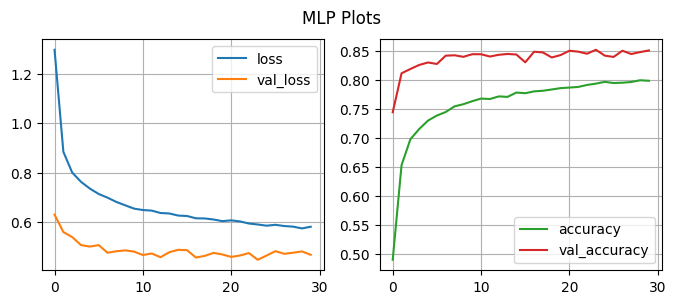

In [95]:
hst_mlp_df[['loss', 'val_loss', 'accuracy', 'val_accuracy']].plot(
    subplots=(('loss', 'val_loss'), ('accuracy', 'val_accuracy')),
    layout=(1, 2), figsize=(8, 3), grid=True)
plt.suptitle('MLP Plots')
plt.show()

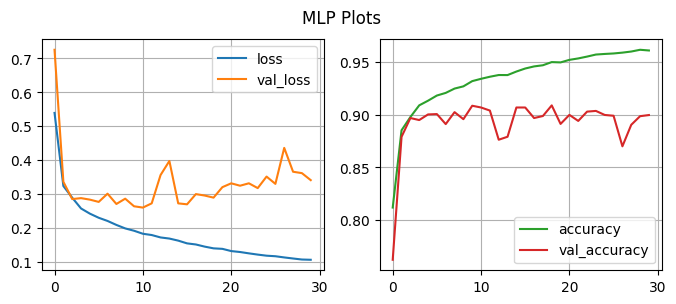

In [101]:
hst_cnn_df[['loss', 'val_loss', 'accuracy', 'val_accuracy']].plot(
    subplots=(('loss', 'val_loss'), ('accuracy', 'val_accuracy')),
    layout=(1, 2), figsize=(8, 3), grid=True)
plt.suptitle('MLP Plots')
plt.show()

In [102]:
test_loss_mlp, test_acc_mlp = model_mlp.evaluate(X_test_mlp, test_labels,
                                                 verbose=0)
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(X_test_cnn, test_labels,
                                                 verbose=0)
print(f'MLP: Loss: {test_loss_mlp:.3f} | Accuracy: {test_acc_mlp*100:.2f} %')
print(f'CNN: Loss: {test_loss_cnn:.3f} | Accuracy: {test_acc_cnn*100:.2f} %')

MLP: Loss: 0.483 | Accuracy: 84.12 %
CNN: Loss: 0.371 | Accuracy: 89.65 %


In [103]:
y_pred_mlp = model_mlp.predict(X_test_mlp, verbose=0)
y_pred_cnn = model_cnn.predict(X_test_cnn, verbose=0)
preds_mlp = y_pred_mlp.argmax(axis=1)
preds_cnn = y_pred_cnn.argmax(axis=1)

In [104]:
print(classification_report(test_labels, preds_mlp,
                            target_names=class_names.values()))

              precision    recall  f1-score   support

 T-shirt/top       0.81      0.77      0.79      1000
     Trouser       0.99      0.94      0.97      1000
    Pullover       0.82      0.64      0.72      1000
       Dress       0.81      0.86      0.83      1000
        Coat       0.66      0.85      0.74      1000
      Sandal       0.97      0.93      0.95      1000
       Shirt       0.58      0.57      0.58      1000
     Sneaker       0.91      0.95      0.93      1000
         Bag       0.97      0.94      0.96      1000
  Ankle boot       0.95      0.95      0.95      1000

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000



In [105]:
print(classification_report(test_labels, preds_cnn,
                            target_names=class_names.values()))

              precision    recall  f1-score   support

 T-shirt/top       0.89      0.78      0.83      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.81      0.88      0.84      1000
       Dress       0.90      0.90      0.90      1000
        Coat       0.89      0.76      0.82      1000
      Sandal       0.99      0.95      0.97      1000
       Shirt       0.68      0.80      0.73      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.95      0.96      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

